<a href="https://colab.research.google.com/github/ksohyun916/DSCI-303-Final-Project-App-Ratings/blob/main/Final_Project_Modeling_Gia_Kim%2C_Shieun_Lee%2C_Wiley_Liou.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [ ]:
#WL FILE UPLOAD
# Upload the file

from google.colab import drive
drive.mount("/content/drive")

path_to_data_folder = "/content/drive/MyDrive/Colab Notebooks/303/"

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/content/drive/MyDrive/Colab Notebooks/303/")

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import skew
from scipy.special import boxcox1p
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Load data
df = pd.read_csv('AppleStore.csv')
y = df['user_rating']

# ------ INITIAL PREPROCESSING ------
# Drop unnecessary columns
df = df.drop(['user_rating', df.columns[0], 'id', 'track_name', 'currency'], axis=1)

# Remove rows with no user rating (0)
rows_to_drop = y[y == 0].index
y = y.drop(rows_to_drop)
df = df.drop(rows_to_drop)

# ------ FEATURE ENGINEERING ------
# Binary feature for free apps
df['is_free'] = np.where(df['price'] == 0, 1, 0)

# Rating ratio
df['rating_ratio'] = np.where(df['rating_count_tot'] == 0, 0, df['rating_count_ver'] / df['rating_count_tot'])

# Version number processing
df['major_ver'] = pd.to_numeric(df['ver'].str.extract(r'^(\d+)')[0], errors='coerce').astype('Int64')
rows_to_drop = df[df['major_ver'] >= 100].index
rows_to_drop = rows_to_drop.union(df[df['major_ver'].isna()].index)
df = df.drop(rows_to_drop)
y = y.drop(rows_to_drop)
df = df.drop('ver', axis=1)

# ------ ENCODING CATEGORICAL FEATURES ------
if 'cont_rating' in df.columns:
    le = LabelEncoder()
    df['cont_rating'] = le.fit_transform(df['cont_rating'])


# ------ HANDLING SKEWNESS AND NORMALIZATION ------
# List of non-binary numerical features to transform
non_binary_features = [
    'size_bytes', 'price', 'rating_count_tot', 'rating_count_ver',
    'user_rating_ver', 'sup_devices.num', 'ipadSc_urls.num',
    'lang.num', 'rating_ratio', 'major_ver'
]

# Filter for features that actually exist in the dataframe
features_to_transform = [f for f in non_binary_features if f in df.columns]

# Handle skewness for selected features
for feat in features_to_transform:
    if abs(skew(df[feat].dropna())) > 0.75:
        df[feat] = boxcox1p(df[feat], 0.15)


# ------ DUMMY ENCODING ------
df = pd.get_dummies(df)
# convert True/False to binary
df = df.astype(float)


# ------ FINAL DATA ------
print("\nProcessed Features Shape:", df.shape)
print("Target Variable Shape:", y.shape)
print("\nFirst 5 rows of processed data:")
print(df.head())


Processed Features Shape: (6237, 36)
Target Variable Shape: (6237,)

First 5 rows of processed data:
   size_bytes     price  rating_count_tot  rating_count_ver  user_rating_ver  \
0   99.117388  1.817786         23.059867          4.263161         1.942540   
1  106.559151  0.000000         33.601265          4.263161         1.687259   
2   99.075749  0.000000         34.565340         15.287420         1.942540   
3  103.044364  0.000000         36.655890         10.946837         1.942540   
4   97.810880  0.000000         46.176040         17.477250         2.055642   

   cont_rating  sup_devices.num  ipadSc_urls.num  lang.num  vpp_lic  ...  \
0          2.0         4.882973         2.055642  2.885846      1.0  ...   
1          2.0         4.838059         2.055642  4.071754      1.0  ...   
2          2.0         4.838059         2.055642  1.540963      1.0  ...   
3          0.0         4.838059         2.055642  2.750250      1.0  ...   
4          2.0         4.838059      

In [ ]:
# Model Evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Train and evaluate model, returning metrics"""
    start_time = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'R2': round(r2_score(y_test, y_pred), 4),
        'Time': round(time.time() - start_time, 4)
    }
    return metrics

# Linear Regression (Baseline Model)


Results for test_size = 0.2:
RMSE: 0.6105
MAE: 0.4446
R2: 0.2359
CV RMSE: 0.6502
Training time: 0.0280 sec

Results for test_size = 0.3:
RMSE: 0.6218
MAE: 0.4517
R2: 0.2346
CV RMSE: 0.6529
Training time: 0.0090 sec

Summary of Results:
   Test Size    RMSE     MAE      R2  CV RMSE   Time
0        0.2  0.6105  0.4446  0.2359   0.6502  0.028
1        0.3  0.6218  0.4517  0.2346   0.6529  0.009

Top 10 Most Important Features:
                         Feature  Coefficient
4                user_rating_ver       0.2230
11                  rating_ratio      -0.1027
3               rating_count_ver       0.0696
20             prime_genre_Games       0.0669
17     prime_genre_Entertainment      -0.0607
32            prime_genre_Sports      -0.0606
34         prime_genre_Utilities      -0.0461
22         prime_genre_Lifestyle      -0.0417
1                          price       0.0363
21  prime_genre_Health & Fitness       0.0300


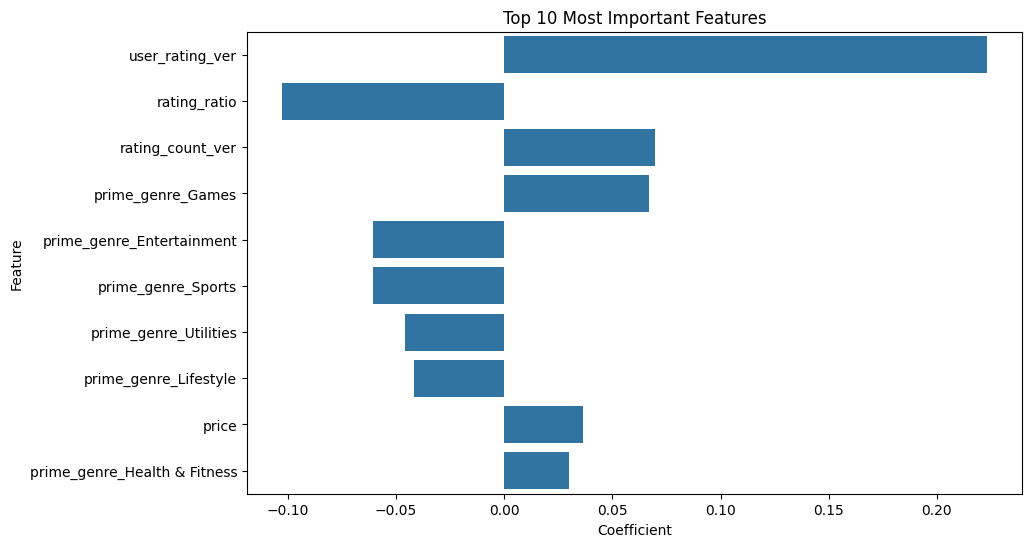

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import time
import pandas as pd


# Initialize results storage
results = []

# Test both split ratios
for test_size in [0.2, 0.3]:
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        df, y, test_size=test_size, random_state=42
    )

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize and train model
    lr = LinearRegression()

    # Get evaluation metrics
    metrics = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test)

    # Cross-validation (5-fold)
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        lr, X_train_scaled, y_train,
        cv=kfold, scoring='neg_mean_squared_error'
    )
    cv_rmse = round(np.mean(np.sqrt(-cv_scores)), 4)

    # Store results
    results.append({
        'Test Size': test_size,
        **metrics,
        'CV RMSE': cv_rmse,
        'Coefficients': lr.coef_
    })

    # Print current results
    print(f"\nResults for test_size = {test_size}:")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"MAE: {metrics['MAE']:.4f}")
    print(f"R2: {metrics['R2']:.4f}")
    print(f"CV RMSE: {cv_rmse:.4f}")
    print(f"Training time: {metrics['Time']:.4f} sec")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\nSummary of Results:")
print(results_df[['Test Size', 'RMSE', 'MAE', 'R2', 'CV RMSE', 'Time']])

# Feature importance analysis
coef_df = pd.DataFrame({
    'Feature': df.columns,
    'Coefficient': results[0]['Coefficients']
}).sort_values('Coefficient', key=abs, ascending=False)
coef_df['Coefficient'] = coef_df['Coefficient'].round(4)

print("\nTop 10 Most Important Features:")
print(coef_df.head(10))

#plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10))
plt.title('Top 10 Most Important Features')
plt.show()

# Ridge and Lasso Regression


Top 5 Models by CV RMSE:
    Model  Test Size  Alpha  Max Iter    RMSE     MAE      R2  CV RMSE    Time
24  Ridge        0.2   0.01      1000  0.6105  0.4446  0.2359   0.6502  0.1596
25  Ridge        0.2   0.01      5000  0.6105  0.4446  0.2359   0.6502  0.0142
26  Ridge        0.2   0.01     10000  0.6105  0.4446  0.2359   0.6502  0.0152
27  Ridge        0.2   0.10      1000  0.6105  0.4446  0.2359   0.6502  0.0142
28  Ridge        0.2   0.10      5000  0.6105  0.4446  0.2359   0.6502  0.0067


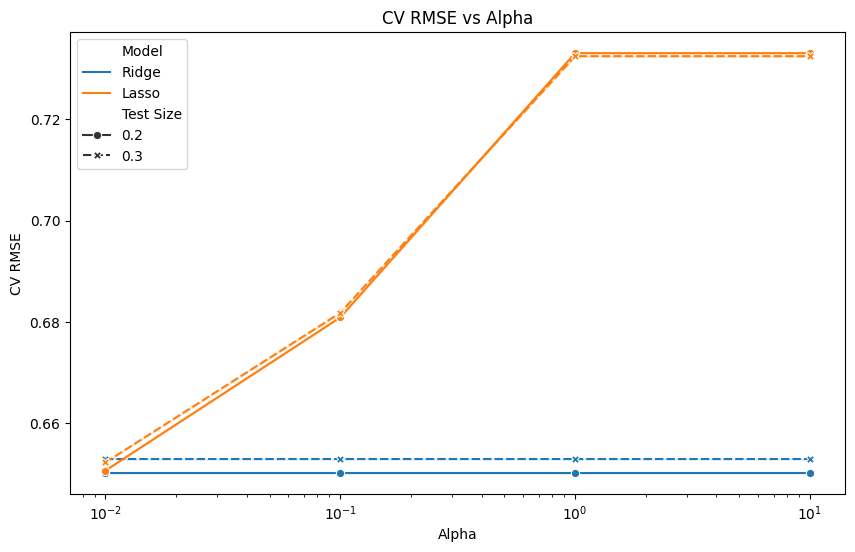

In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Define hyperparameter grid
alphas = [0.01, 0.1, 1, 10]
max_iters = [1000, 5000, 10000]

# Store all results
all_results = []

# Loop over models
for model_name, Model in [('Lasso', Lasso), ('Ridge', Ridge)]:
    for test_size in [0.2, 0.3]:
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=test_size, random_state=42)

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        for alpha in alphas:
            for max_iter in max_iters:
                model = Model(alpha=alpha, max_iter=max_iter, random_state=42)

                # Evaluate model
                metrics = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)

                # Cross-validation
                kfold = KFold(n_splits=5, shuffle=True, random_state=42)
                cv_scores = cross_val_score(
                    model, X_train_scaled, y_train,
                    cv=kfold, scoring='neg_mean_squared_error'
                )
                cv_rmse = round(np.mean(np.sqrt(-cv_scores)), 4)

                # Store results
                all_results.append({
                    'Model': model_name,
                    'Test Size': test_size,
                    'Alpha': alpha,
                    'Max Iter': max_iter,
                    **metrics,
                    'CV RMSE': cv_rmse,
                    'Coefficients': model.coef_
                })

# Create dataframe from results
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by='CV RMSE')  # Sort by CV performance

# Print top 5 models
print("\nTop 5 Models by CV RMSE:")
print(results_df[['Model', 'Test Size', 'Alpha', 'Max Iter', 'RMSE', 'MAE', 'R2', 'CV RMSE', 'Time']].head())

# Plot CV RMSE vs Alpha for each model
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x='Alpha', y='CV RMSE', hue='Model', style='Test Size', markers=True)
plt.title("CV RMSE vs Alpha")
plt.xscale('log')
plt.show()


Best Model:
Model         Ridge
Test Size       0.2
Alpha          0.01
Max Iter       1000
RMSE         0.6105
MAE          0.4446
R2           0.2359
CV RMSE      0.6502
Time         0.1596
Name: 24, dtype: object

Top 10 Most Important Features:
                         Feature  Coefficient
4                user_rating_ver       0.2230
11                  rating_ratio      -0.1027
3               rating_count_ver       0.0696
20             prime_genre_Games       0.0669
17     prime_genre_Entertainment      -0.0607
32            prime_genre_Sports      -0.0606
34         prime_genre_Utilities      -0.0461
22         prime_genre_Lifestyle      -0.0417
1                          price       0.0363
21  prime_genre_Health & Fitness       0.0300


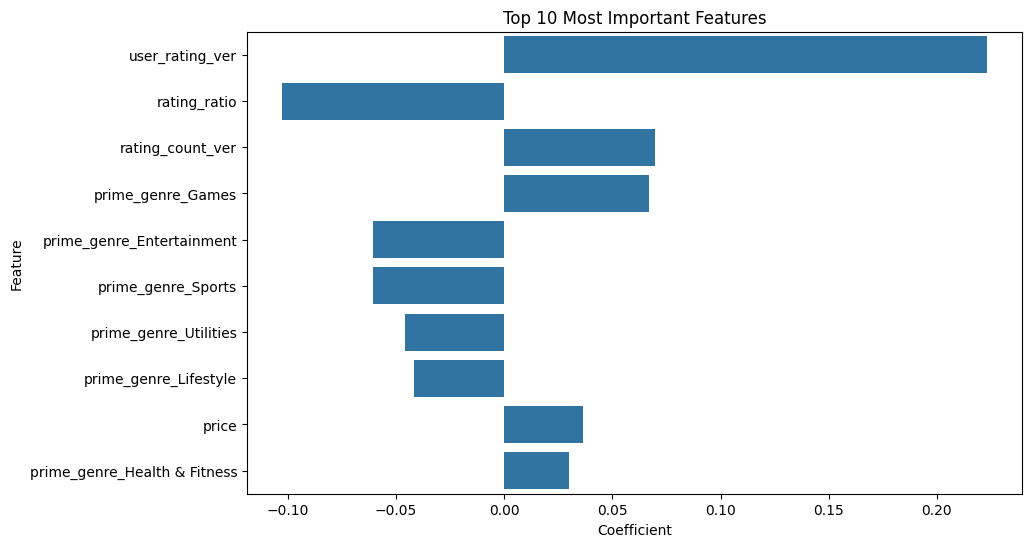

In [ ]:
# Plot the feature importance of the best model
best_model = results_df.iloc[0]
coef_df = pd.DataFrame({
    'Feature': df.columns,
    'Coefficient': best_model['Coefficients']
}).sort_values('Coefficient', key=abs, ascending=False)
coef_df['Coefficient'] = coef_df['Coefficient'].round(4)

# print what the best model is
print("\nBest Model:")
print(best_model[['Model', 'Test Size', 'Alpha', 'Max Iter', 'RMSE', 'MAE', 'R2', 'CV RMSE', 'Time']])
print("\nTop 10 Most Important Features:")
print(coef_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10))
plt.title('Top 10 Most Important Features')
plt.show()


# Regression Using PCA

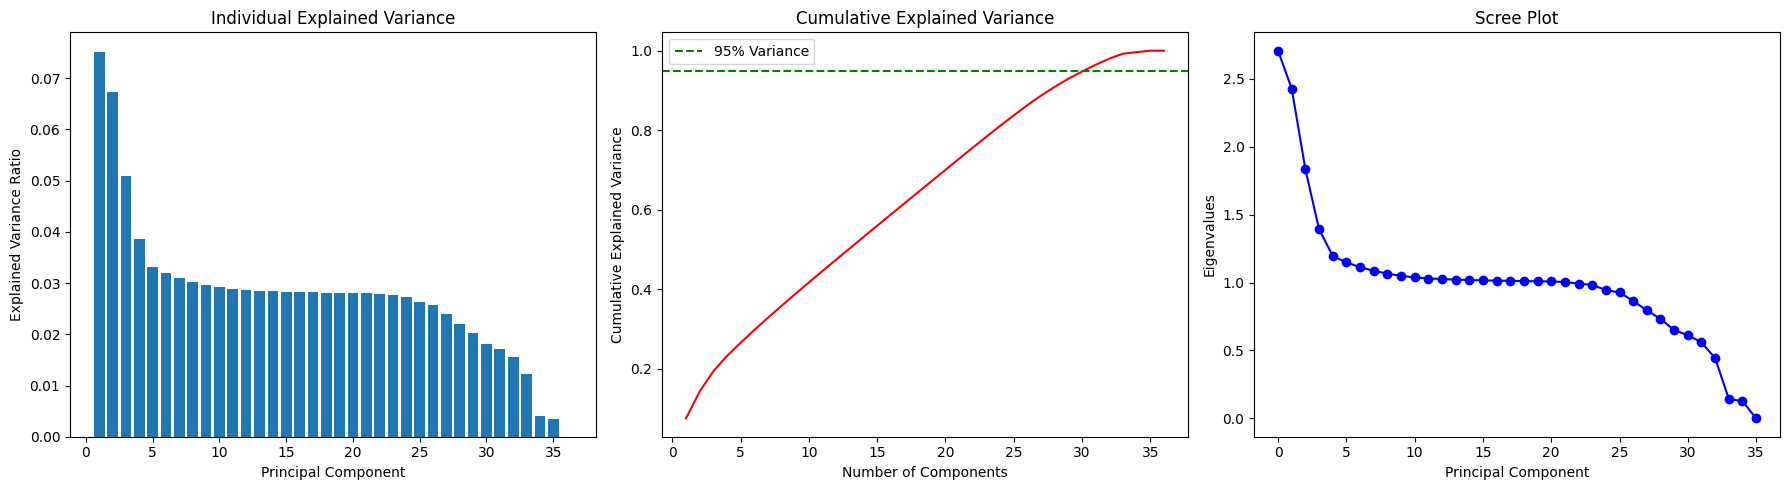


Number of components retaining 95% variance: 31

Ridge Regression with PCA Performance:
     RMSE     MAE      R2    Time
0  0.6218  0.4517  0.2346  0.0111


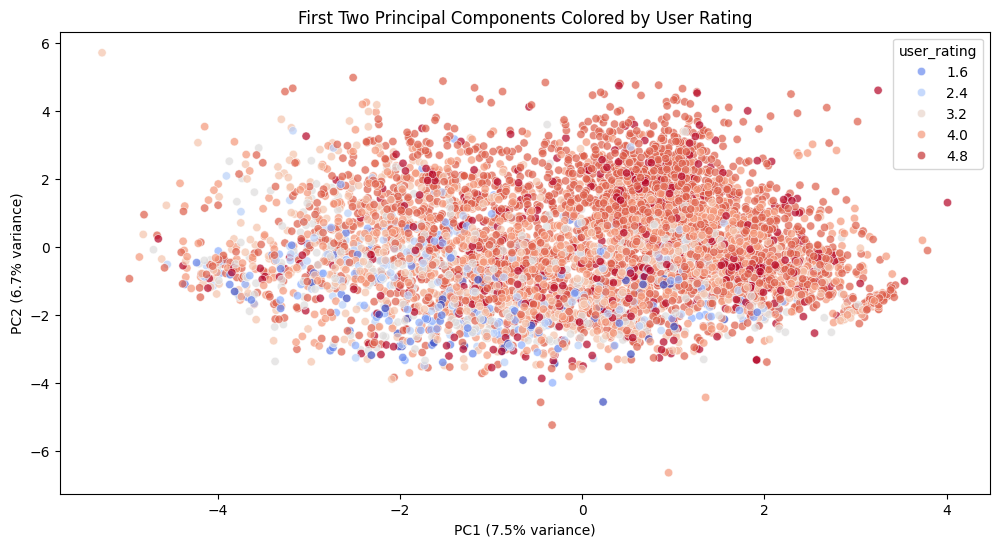

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize the data
X_scaled = StandardScaler().fit_transform(df)

# Fit PCA to get variance information
pca = PCA().fit(X_scaled)

plt.figure(figsize=(18, 5))
# Plot 1: Explained Variance Ratio per Component
plt.subplot(1, 3, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance')

# Plot 2: Cumulative Explained Variance
plt.subplot(1, 3, 2)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), 'r-')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()

# Plot 3: Scree Plot (Eigenvalues)
plt.subplot(1, 3, 3)
plt.plot(pca.explained_variance_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalues')
plt.title('Scree Plot')

plt.tight_layout()
plt.show()

# Determine optimal number of components (95% variance)
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"\nNumber of components retaining 95% variance: {n_components}")

# Transform data with optimal components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Train/test split with PCA-transformed data
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# Train and evaluate best model
ridge_pca = Ridge(alpha=0.01, max_iter=1000)
start_time = time.time()
ridge_pca.fit(X_train_pca, y_train)
y_pred = ridge_pca.predict(X_test_pca)

# Evaluate performance
evaluate_model(ridge_pca, X_train_pca, X_test_pca, y_train, y_test)

print("\nRidge Regression with PCA Performance:")
print(pd.DataFrame([metrics]))

# Visualize component relationships
plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('First Two Principal Components Colored by User Rating')
plt.show()



In [ ]:
# Create loadings matrix
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i}' for i in range(1, n_components+1)],
    index=df.columns
)

# Top 3 features per PC
for pc in loadings.columns[:5]:  # First 5 PCs
    print(f"\nTop features for {pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(3))


Top features for PC1:
prime_genre_Games    0.460431
major_ver            0.372197
rating_ratio         0.307171
Name: PC1, dtype: float64

Top features for PC2:
rating_count_tot    0.504573
is_free             0.424264
price               0.400850
Name: PC2, dtype: float64

Top features for PC3:
price       0.419270
lang.num    0.372614
is_free     0.347345
Name: PC3, dtype: float64

Top features for PC4:
size_bytes          0.470584
ipadSc_urls.num     0.353182
rating_count_ver    0.343664
Name: PC4, dtype: float64

Top features for PC5:
cont_rating         0.456640
vpp_lic             0.345599
prime_genre_News    0.326787
Name: PC5, dtype: float64


# Decision Tree

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10}

Decision Tree Performance:
Decision Tree | RMSE: 0.4995 | R2: 0.4885


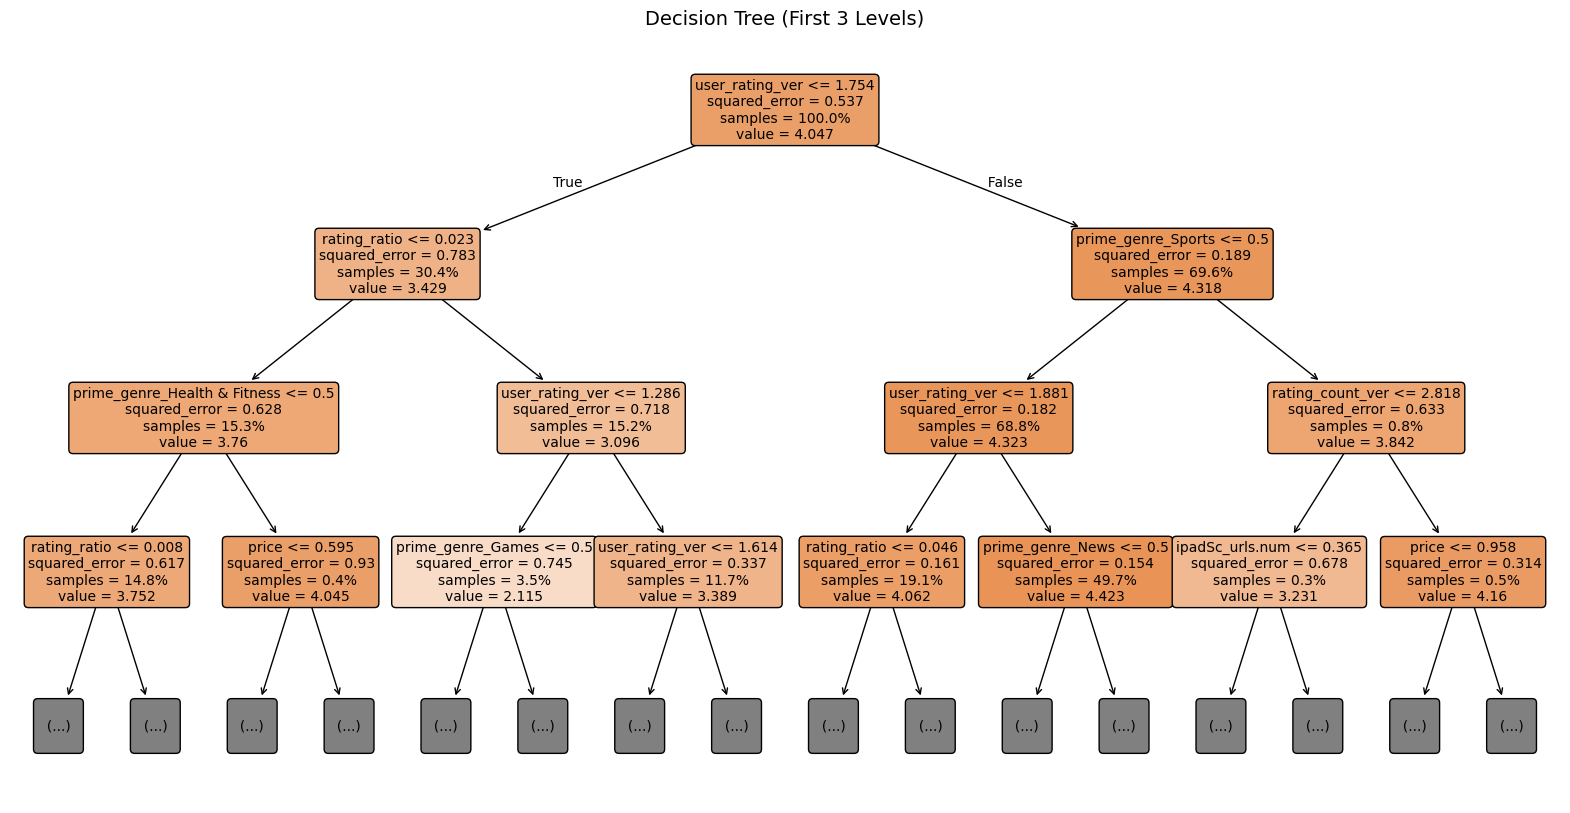


Top 10 Important Features:
               Feature  Importance
4      user_rating_ver    0.709187
11        rating_ratio    0.143108
2     rating_count_tot    0.023856
3     rating_count_ver    0.020402
32  prime_genre_Sports    0.012096
12           major_ver    0.012078
0           size_bytes    0.011733
20   prime_genre_Games    0.011498
7      ipadSc_urls.num    0.009374
8             lang.num    0.008282


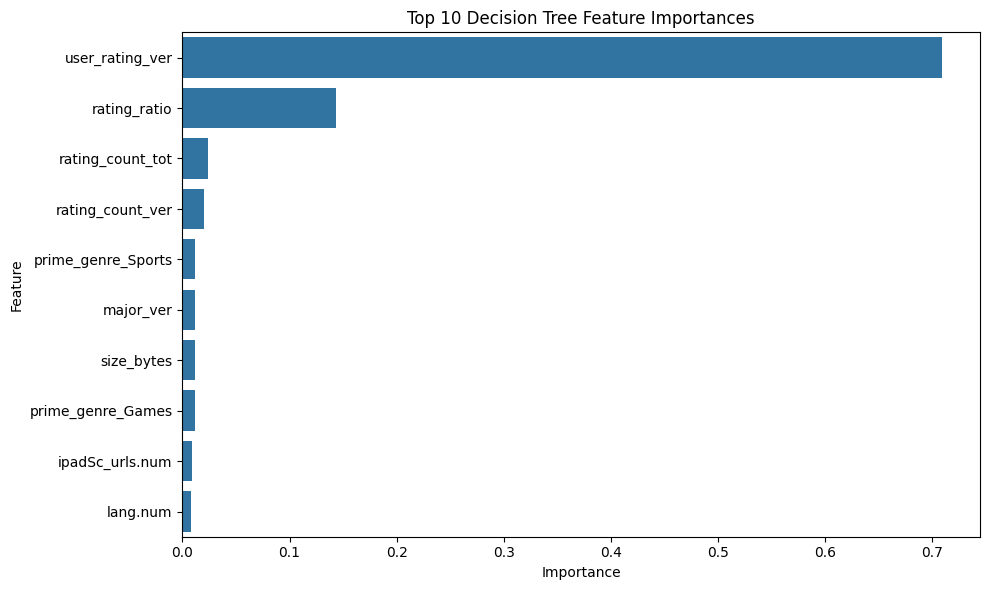

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
import matplotlib.pyplot as plt

# Prepare data
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42
)

# Define parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Initialize and run GridSearchCV
dtree = DecisionTreeRegressor(random_state=42)
grid_search_dt = GridSearchCV(estimator=dtree, param_grid=param_grid_dt, cv=5, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

grid_search_dt.fit(X_train, y_train)

# Get best model
best_dt_model = grid_search_dt.best_estimator_
print("\nBest Parameters:", grid_search_dt.best_params_)

# Prediction
print("\nDecision Tree Performance:")
dt_metrics = evaluate_model(best_dt_model, X_train, X_test, y_train, y_test)

# Results
print(f"Decision Tree | RMSE: {dt_metrics['RMSE']} | R2: {dt_metrics['R2']}")

# Visualize the tree
plt.figure(figsize=(20,10))
plot_tree(
    best_dt_model,
    filled=True,
    feature_names=df.columns,
    max_depth=3,
    fontsize=10,
    proportion=True,
    rounded=True
)
plt.title("Decision Tree (First 3 Levels)", fontsize=14)
plt.show()

# Feature Importance Analysis
importance = pd.DataFrame({
    'Feature': df.columns,
    'Importance': best_dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title("Top 10 Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

# Random Forest

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Grid Search completed in 219.81 seconds

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest Performance:


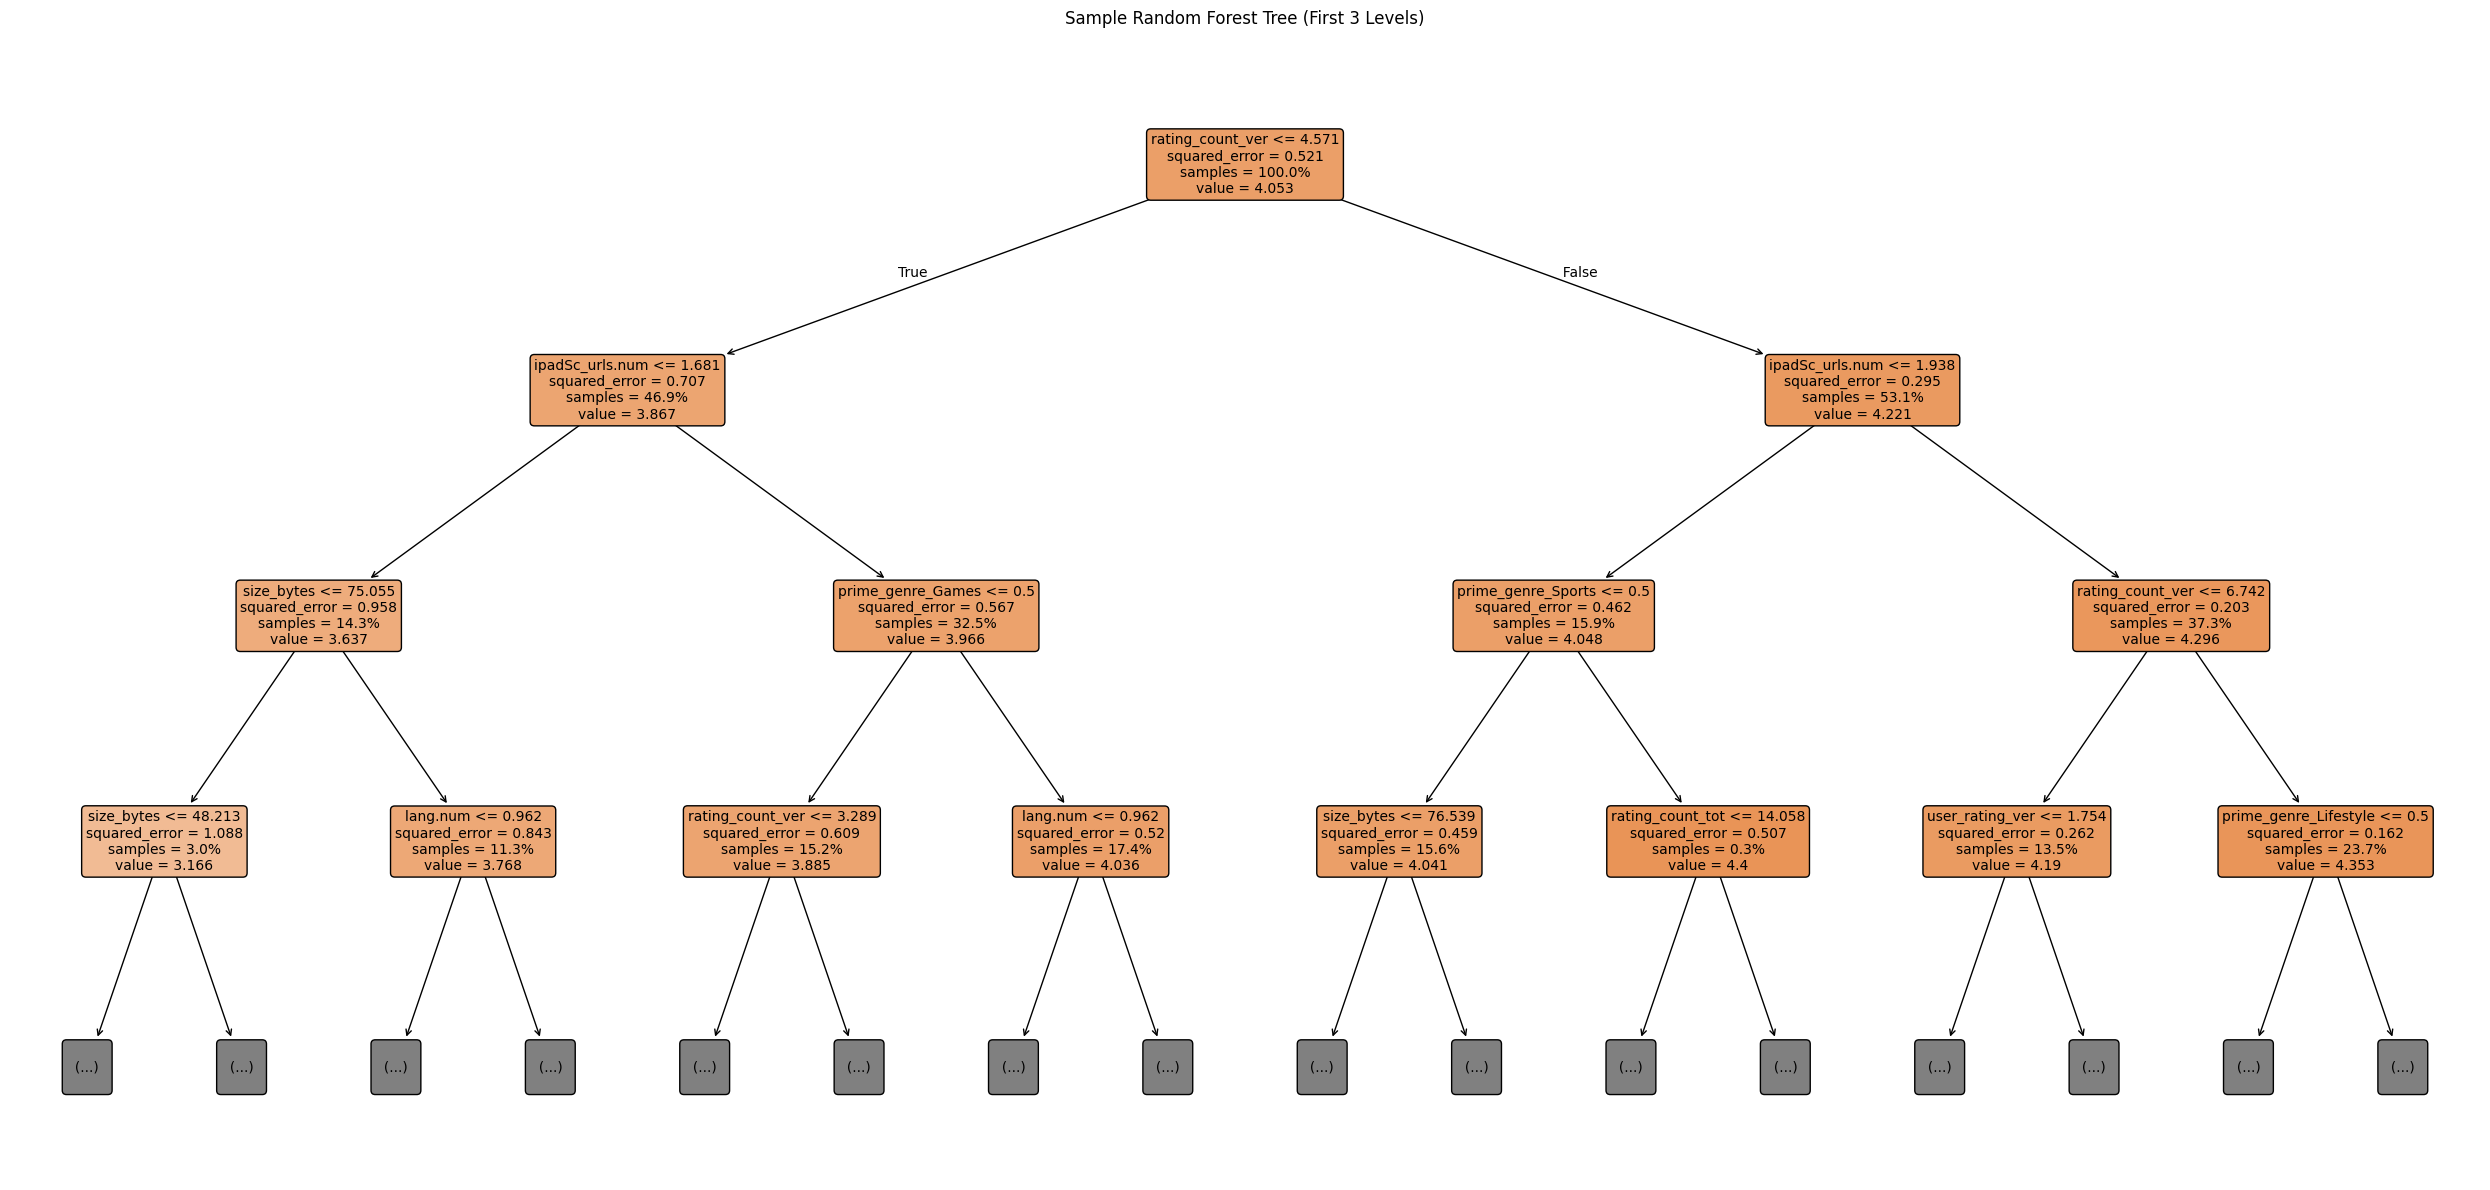


Top 10 Features:
             Feature  Importance
4    user_rating_ver    0.328640
2   rating_count_tot    0.113925
0         size_bytes    0.093548
11      rating_ratio    0.086608
3   rating_count_ver    0.080673
8           lang.num    0.036972
12         major_ver    0.035216
7    ipadSc_urls.num    0.032405
6    sup_devices.num    0.029114
1              price    0.027518
Random Forest | RMSE: 0.4652 | R2: 0.5564


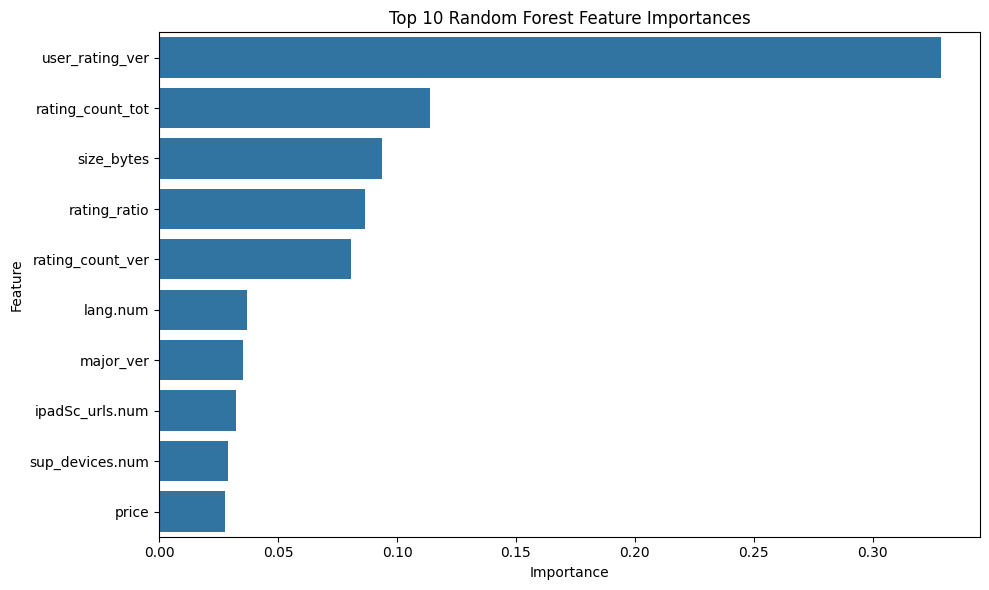

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import time

# Define parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Initialize model with random state for reproducibility
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Grid Search setup (using your existing evaluation metrics)
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
)

start_time = time.time()
grid_search_rf.fit(X_train, y_train)
print(f"Grid Search completed in {time.time()-start_time:.2f} seconds")

# Get best model
best_rf_model = grid_search_rf.best_estimator_
print("\nBest Parameters:", grid_search_rf.best_params_)

# Evaluate using your existing function
print("\nRandom Forest Performance:")
rf_metrics = evaluate_model(best_rf_model, X_train, X_test, y_train, y_test)


# Visualize a sample tree (simplified)
plt.figure(figsize=(25, 12))
plot_tree(
    best_rf_model.estimators_[0],
    filled=True,
    feature_names=X_train.columns,
    max_depth=3,
    fontsize=10,
    proportion=True,
    rounded=True
)
plt.title("Sample Random Forest Tree (First 3 Levels)", pad=20)
plt.tight_layout()
plt.show()

# Feature Importance Analysis
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(feature_imp.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(10))
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()

# Results
print(f"Random Forest | RMSE: {rf_metrics['RMSE']:.4f} | R2: {rf_metrics['R2']:.4f}")

### kNN Classification Model

kNN Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.12      0.20         8
           2       0.27      0.26      0.27        66
           3       0.12      0.05      0.07        66
           4       0.84      0.95      0.89      1008
           5       0.52      0.12      0.20       100

    accuracy                           0.79      1248
   macro avg       0.45      0.30      0.32      1248
weighted avg       0.75      0.79      0.76      1248



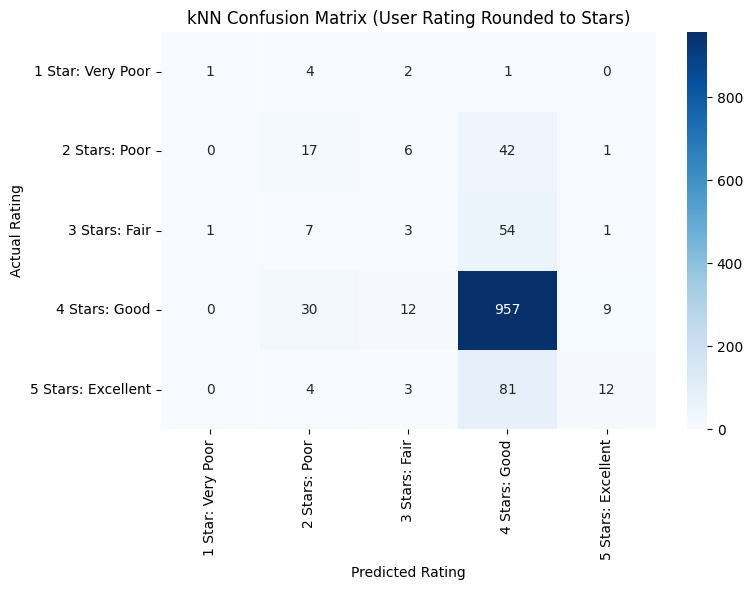

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Convert user_rating into classes (e.g., rounded star ratings)
y_class = y.round().astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(df, y_class, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# kNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)

# Evaluation
print("kNN Classification Report:")
print(classification_report(y_test, knn_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, knn_preds)
labels = sorted(y_class.unique())
label_map = {
    1: '1 Star: Very Poor',
    2: '2 Stars: Poor',
    3: '3 Stars: Fair',
    4: '4 Stars: Good',
    5: '5 Stars: Excellent'
}
tick_labels = [label_map.get(l, str(l)) for l in labels]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=tick_labels, yticklabels=tick_labels)
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("kNN Confusion Matrix (User Rating Rounded to Stars)")
plt.tight_layout()
plt.show()

### kNN Regressor Model

kNN Regressor Mean Absolute Error: 0.432
kNN Regressor R² Score: 0.262


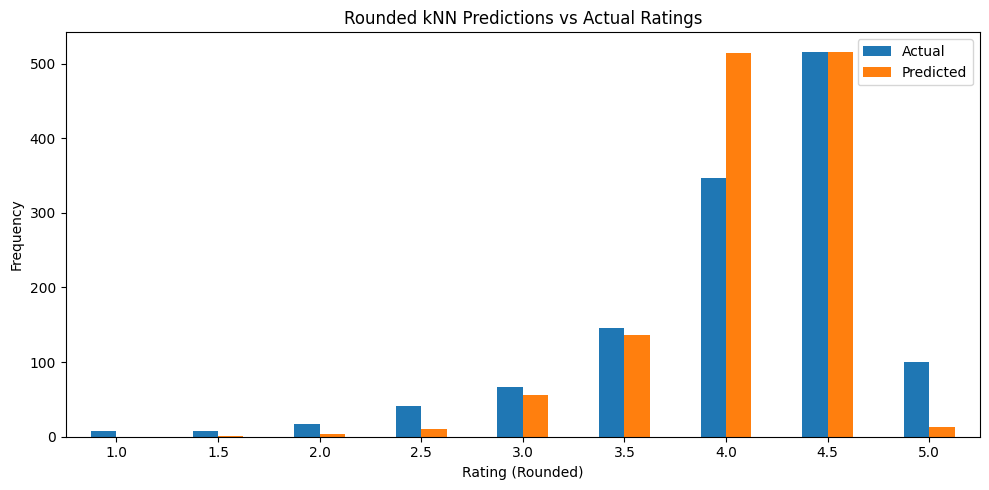

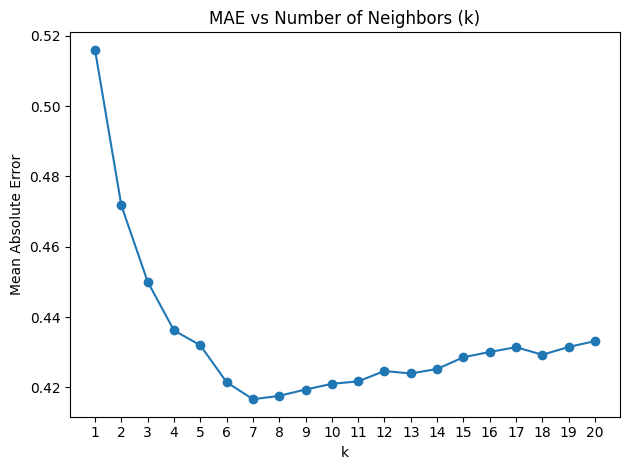

In [ ]:
# kNN regressor to predict more specific rating
from sklearn.neighbors import KNeighborsRegressor

# Use original user rating as target (not rounded ver for knn classifier)
X = df
y = y

# Train/test split again using original target and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features again
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train kNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)
y_pred = knn_reg.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("kNN Regressor Mean Absolute Error:", round(mae, 3))
print("kNN Regressor R² Score:", round(r2, 3))

# Bar chart for rounded predictions vs actual
rounded_preds = np.round(y_pred * 2) / 2
rounded_actuals = np.round(y_test * 2) / 2

# Frequency counts
actual_counts = pd.Series(rounded_actuals).value_counts().sort_index()
pred_counts = pd.Series(rounded_preds).value_counts().sort_index()

# Plot
compare_counts = pd.DataFrame({'Actual': actual_counts, 'Predicted': pred_counts}).fillna(0)
compare_counts.plot(kind='bar', figsize=(10, 5))
plt.title("Rounded kNN Predictions vs Actual Ratings")
plt.xlabel("Rating (Rounded)")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Line plot for MAE vs k
from sklearn.metrics import mean_absolute_error
mae_scores = []
k_values = range(1, 21)
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae_scores.append(mean_absolute_error(y_test, preds))

plt.plot(k_values, mae_scores, marker='o')
plt.title("MAE vs Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("Mean Absolute Error")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### SVM

SVR Mean Absolute Error: 0.336
SVR R² Score: 0.502


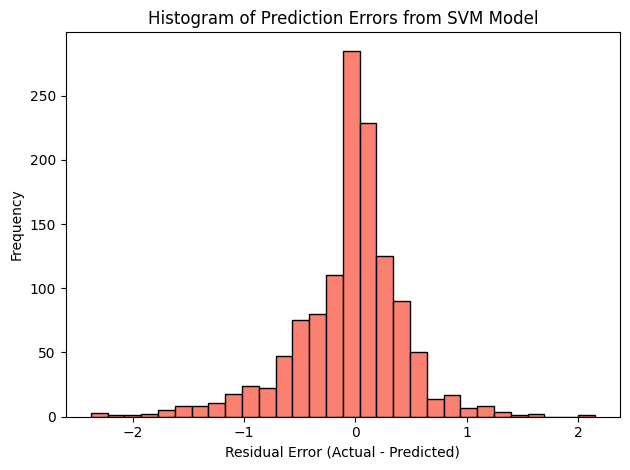

In [ ]:
from sklearn.svm import SVR

# Train SVR
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("SVR Mean Absolute Error:", round(mae, 3))
print("SVR R² Score:", round(r2, 3))

# create histogram of residuals
residuals = y_test - y_pred
plt.hist(residuals, bins=30, color='salmon', edgecolor='black')
plt.title("Histogram of Prediction Errors from SVM Model")
plt.xlabel("Residual Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Parameter combinations to be tested:
    kernel     C  epsilon
0      rbf   0.1      0.1
1      rbf   0.1      0.5
2      rbf   1.0      0.1
3      rbf   1.0      0.5
4      rbf  10.0      0.1
5      rbf  10.0      0.5
6   linear   0.1      0.1
7   linear   0.1      0.5
8   linear   1.0      0.1
9   linear   1.0      0.5
10  linear  10.0      0.1
11  linear  10.0      0.5
12    poly   0.1      0.1
13    poly   0.1      0.5
14    poly   1.0      0.1
15    poly   1.0      0.5
16    poly  10.0      0.1
17    poly  10.0      0.5

Total combinations to test: 18

Starting grid search...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best parameters found:
{'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}

Evaluation Metrics:
RMSE: 0.4929
MAE: 0.3363
R2: 0.5018
Time: 1.6188


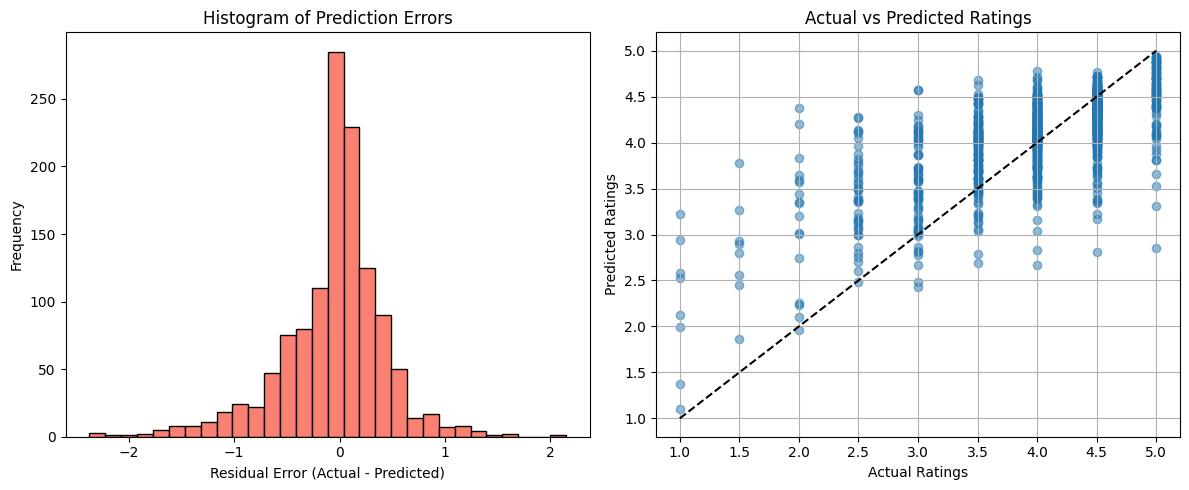

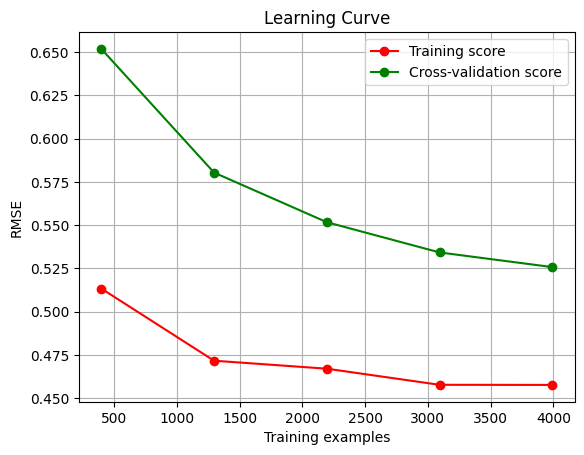

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Parameter Grid
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.5],
}

# Print all parameter combinations being tested
print("Parameter combinations to be tested:")
all_params = []
for kernel in param_grid['kernel']:
    for c in param_grid['C']:
        for epsilon in param_grid['epsilon']:
            all_params.append({'kernel': kernel, 'C': c, 'epsilon': epsilon})

params_df = pd.DataFrame(all_params)
print(params_df)
print(f"\nTotal combinations to test: {len(params_df)}")

# Initialize and run grid search
svr = SVR()
grid_search = GridSearchCV(estimator=svr,
                         param_grid=param_grid,
                         cv=3,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1,
                         verbose=1)

print("\nStarting grid search...")
grid_search.fit(X_train_scaled, y_train)

# Best model evaluation
best_svr = grid_search.best_estimator_
print("\nBest parameters found:")
print(grid_search.best_params_)

# Evaluate using your function
svr_metrics = evaluate_model(best_svr, X_train_scaled, X_test_scaled, y_train, y_test)
print("\nEvaluation Metrics:")
for metric, value in svr_metrics.items():
    print(f"{metric}: {value}")

# Visualization 1: Residual plot
plt.figure(figsize=(12, 5))
residuals = y_test - best_svr.predict(X_test_scaled)

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, color='salmon', edgecolor='black')
plt.title("Histogram of Prediction Errors")
plt.xlabel("Residual Error (Actual - Predicted)")
plt.ylabel("Frequency")

# Visualization 2: Actual vs Predicted
plt.subplot(1, 2, 2)
y_pred = best_svr.predict(X_test_scaled)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings')
plt.grid(True)

plt.tight_layout()
plt.show()

# Learning curve visualization
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_svr, X_train_scaled, y_train, cv=5,
    scoring='neg_mean_squared_error', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5))

train_scores_mean = np.mean(np.sqrt(-train_scores), axis=1)
test_scores_mean = np.mean(np.sqrt(-test_scores), axis=1)

plt.figure()
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid()
plt.show()

# Neural Network


Testing lr=0.001, hls=(50,)
New best validation RMSE: 0.5656

Testing lr=0.001, hls=(100,)

Testing lr=0.001, hls=(50, 50)
New best validation RMSE: 0.5520

Testing lr=0.001, hls=(100, 100)

Testing lr=0.01, hls=(50,)
New best validation RMSE: 0.5476

Testing lr=0.01, hls=(100,)
New best validation RMSE: 0.5452

Testing lr=0.01, hls=(50, 50)

Testing lr=0.01, hls=(100, 100)

Testing lr=0.1, hls=(50,)

Testing lr=0.1, hls=(100,)

Testing lr=0.1, hls=(50, 50)

Testing lr=0.1, hls=(100, 100)

Best Parameters: {'learning_rate': 0.01, 'hidden_layer_sizes': (100,)}

Final Test Metrics:
RMSE: 0.5137
MAE: 0.4118
R2: 0.459
Time: 3.1322


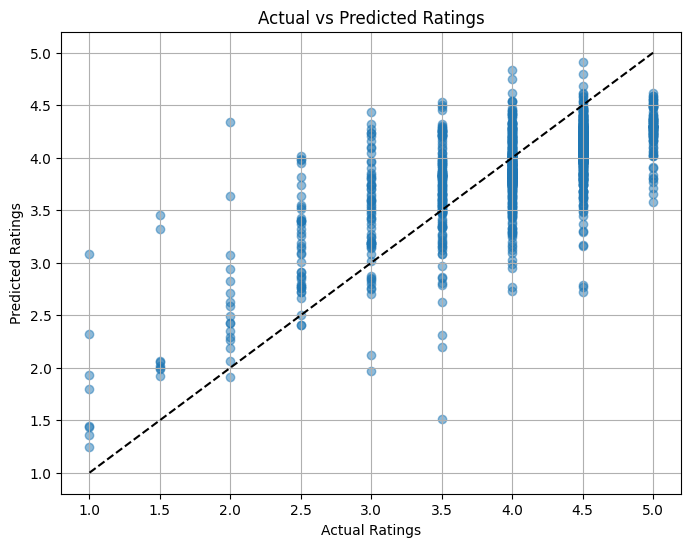

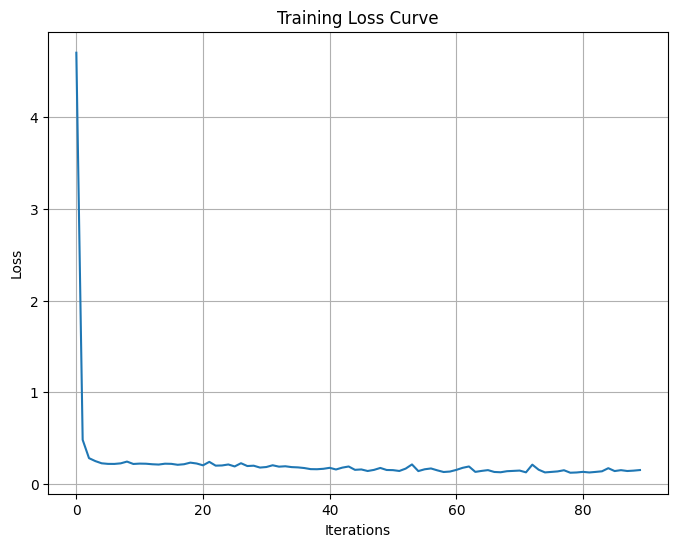

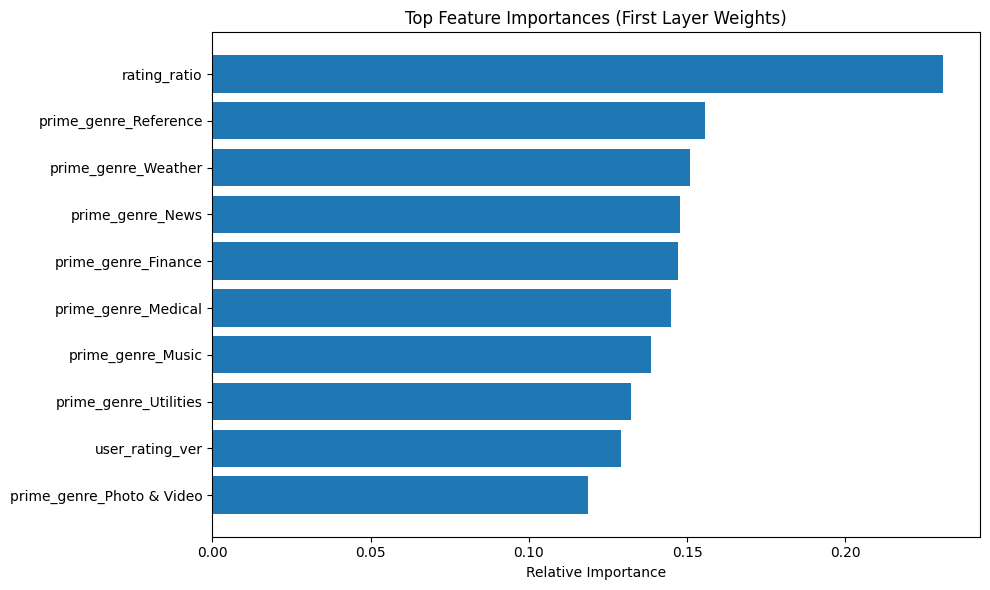

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Split into training, validation, and test sets
X_train_, X_test, y_train_, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_, y_train_, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Parameter grid for tuning
learning_rates = [0.001, 0.01, 0.1]
hidden_layer_sizes = [(50,), (100,), (50, 50), (100, 100)]
best_score = np.inf
best_params = {}

# Grid search with evaluation
for lr in learning_rates:
    for hls in hidden_layer_sizes:
        print(f"\nTesting lr={lr}, hls={hls}")

        # Create and train model
        mlp = MLPRegressor(hidden_layer_sizes=hls,
                          learning_rate_init=lr,
                          max_iter=1000,
                          random_state=42,
                          early_stopping=True)

        # Evaluate using your function (on validation set)
        val_metrics = evaluate_model(mlp, X_train, X_val, y_train, y_val)

        # Track best model based on RMSE
        if val_metrics['RMSE'] < best_score:
            best_score = val_metrics['RMSE']
            best_params = {'learning_rate': lr, 'hidden_layer_sizes': hls}
            best_mlp = mlp  # Keep reference to best model
            print(f"New best validation RMSE: {best_score:.4f}")

# Print the best parameters
print("\nBest Parameters:", best_params)
final_mlp = MLPRegressor(hidden_layer_sizes=best_params['hidden_layer_sizes'],
                        learning_rate_init=best_params['learning_rate'],
                        max_iter=1000,
                        random_state=42)

# Evaluate on test set using your function
test_metrics = evaluate_model(final_mlp, X_train_, X_test, y_train_, y_test)
print("\nFinal Test Metrics:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value}")

# Visualization 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
y_pred = final_mlp.predict(X_test)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings')
plt.grid(True)
plt.show()

# Visualization 2: Loss Curve
if hasattr(final_mlp, 'loss_curve_'):
    plt.figure(figsize=(8, 6))
    plt.plot(final_mlp.loss_curve_)
    plt.title('Training Loss Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

# Visualization 3: Feature Importance (first layer weights)
if hasattr(final_mlp, 'coefs_'):
    importance = np.mean(np.abs(final_mlp.coefs_[0]), axis=1)
    top_features = 10  # Show top 10 features
    indices = np.argsort(importance)[-top_features:]

    plt.figure(figsize=(10, 6))
    plt.title('Top Feature Importances (First Layer Weights)')
    plt.barh(range(top_features), importance[indices], align='center')
    plt.yticks(range(top_features), [X.columns[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.show()